# Atraso de entrega e insatisfação no e-commerce

## Uma análise para priorização do atendimento ao cliente

| | |
|---|---|
| **Estudante** | Tiago Andre Gondim |
| **Matrícula** | 231013476 |
| **Disciplina** | EPR0074 — Projeto de Sistemas de Produção 3 |
| **Turma** | T03 — 2026.2 |
| **Professor** | Andre Luiz Marques Serrano |
| **Modalidade** | Atividade individual |
| **Fonte dos dados** | Brazilian E-Commerce Public Dataset by Olist (Kaggle), versão 2 |

---

## 1. Resumo executivo

<!-- RESUMO_EXECUTIVO_INICIO -->
**Pedidos entregues depois da data prometida têm risco muito maior de receber avaliação ruim:
62,42% contra 9,27% dos entregues no prazo.** A diferença é de 53,2 pontos percentuais
(IC 95%: 51,9 a 54,3 p.p.) e corresponde a um risco relativo de 6,74x (IC 95%: 6,55 a 6,93).
A base analisada reúne 95.824 pedidos entregues, de compras realizadas entre setembro de 2016 e
agosto de 2018.

**O risco cresce com a duração do atraso até um patamar, e não além dele.** Parte de 9,27% nos
pedidos no prazo, chega a 32,13% com 1 a 3 dias de atraso, 67,68% com 4 a 7 dias e 80,15% com
8 a 14 dias. Acima de 14 dias não há aumento adicional detectável: a faixa de 15 dias ou mais
registra 78,35%, estatisticamente indistinguível da faixa anterior.

**Isso sustenta uma triagem em três níveis.** Atrasos de 1 a 3 dias justificam contato humano
proativo, cerca de 77 pedidos por mês no período analisado. Atrasos de 4 dias ou mais justificam
escalonamento e avaliação de compensação, cerca de 189 pedidos por mês. Os demais seguem o
acompanhamento normal. A regra usa apenas informação já disponível no momento da entrega e não
exige modelo preditivo.

**Limite da evidência.** Os dados são observacionais. Eles mostram que atraso e avaliação ruim
estão fortemente associados, o que permite selecionar clientes por risco. Não demonstram que o
atraso cause a nota baixa, nem que o contato proativo melhore a avaliação. Comprovar o efeito da
ação exige teste A/B.
<!-- RESUMO_EXECUTIVO_FIM -->

*Cada número deste resumo é conferido automaticamente contra o valor recalculado pela análise. A
verificação está na seção 16 e interrompe o notebook em caso de divergência.*

## 2. Situação-problema e decisão apoiada

Uma operação de comércio eletrônico tem capacidade limitada de atendimento e não consegue
contatar todos os clientes cujos pedidos atrasam. É preciso escolher quais pedidos recebem
acompanhamento proativo.

**A decisão apoiada por esta análise é de alocação de capacidade de atendimento:** dado um
pedido entregue com atraso, qual deve ser a intensidade do contato com o cliente.

A análise mede a associação entre atraso e avaliação negativa. Ela não demonstra que contatar
o cliente melhora a nota. Essa fronteira é tratada explicitamente na seção 15.

## 3. Pergunta, objetivo e hipóteses

**Pergunta.** Pedidos entregues depois da data prometida apresentam maior risco de receber
avaliações ruins? Como esse risco varia conforme o número de dias de atraso?

**Objetivo.** Quantificar a associação entre atraso e avaliação negativa e propor uma regra
simples e auditável de priorização do atendimento.

**Hipóteses, fixadas antes da observação dos resultados:**

- $H_0$: a proporção de avaliações ruins é **igual** entre pedidos atrasados e pedidos no prazo.
- $H_1$: a proporção de avaliações ruins é **maior** entre pedidos atrasados.

A alternativa é direcional porque a hipótese de interesse tem direção definida pelo problema de
negócio. Não haveria sentido operacional em priorizar atendimento se o atraso reduzisse o risco
de avaliação ruim.

## 4. Fonte, escopo e dicionário das variáveis

Os dados vêm do [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce),
conjunto público e anonimizado de pedidos realizados em marketplaces brasileiros. Para manter o
escopo proporcional à atividade, apenas dois arquivos são utilizados:

- `olist_orders_dataset.csv`, um registro por pedido, com status e datas;
- `olist_order_reviews_dataset.csv`, as avaliações enviadas pelos clientes.

A **versão 2** do conjunto é fixada no identificador de download, de modo que qualquer reexecução
leia exatamente os mesmos dados.

### Variáveis lidas dos arquivos

| Variável | Origem | Descrição |
|---|---|---|
| `order_id` | pedidos e avaliações | Identificador do pedido. Unidade de análise. |
| `order_status` | pedidos | Situação do pedido. Apenas `delivered` é analisado. |
| `order_purchase_timestamp` | pedidos | Data da compra. Usada para delimitar o período. |
| `order_delivered_customer_date` | pedidos | Data e hora da entrega efetiva ao cliente. |
| `order_estimated_delivery_date` | pedidos | Data prometida de entrega. |
| `review_id` | avaliações | Identificador da avaliação. Usado como critério de desempate. |
| `review_score` | avaliações | Nota de 1 a 5 atribuída pelo cliente. |
| `review_answer_timestamp` | avaliações | Data e hora da resposta. Usada para escolher a avaliação mais recente. |

### Variáveis construídas

| Variável | Definição |
|---|---|
| `atraso_dias` | Data de entrega efetiva menos data estimada, ambas normalizadas para o início do dia, em dias inteiros. |
| `pedido_atrasado` | Verdadeiro quando `atraso_dias > 0`. |
| `avaliacao_ruim` | Verdadeiro quando `review_score <= 2`. |
| `faixa_atraso` | Categoria ordenada: no prazo ou antecipado; 1 a 3 dias; 4 a 7 dias; 8 a 14 dias; 15 dias ou mais. |

**Convenção de calendário.** As datas são normalizadas para o início do dia antes da subtração.
Uma entrega realizada no próprio dia prometido é considerada no prazo, qualquer que seja o
horário. A escolha reflete a promessa comercial, que é feita em data e não em horário.

Notas 4 e 5 são tratadas como positivas e a nota 3 como neutra. A inferência principal usa
somente a variável binária `avaliacao_ruim`.

## 5. Configuração do ambiente e importações

O ambiente não fixa versões, para funcionar tanto no Google Colab quanto em execução local. As
versões efetivamente utilizadas ficam registradas na seção 16.

In [1]:
import importlib.util
import subprocess
import sys

for pacote in ["kagglehub", "statsmodels"]:
    if importlib.util.find_spec(pacote) is None:
        print(f"Instalando {pacote}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pacote])

print("Dependências disponíveis.")

Dependências disponíveis.


In [2]:
%matplotlib inline
import datetime
import warnings
import zipfile

# A barra de progresso do kagglehub avisa quando ipywidgets não está disponível. O aviso
# carrega o caminho de instalação da máquina que executa e não deve entrar no arquivo entregue.
warnings.filterwarnings("ignore", message=".*IProgress.*")

import kagglehub
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels
from IPython.display import Markdown, display
from statsmodels.stats.contingency_tables import Table
from statsmodels.stats.proportion import (
    confint_proportions_2indep,
    proportion_confint,
    proportions_ztest,
    test_proportions_2indep,
)

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

# Paleta Okabe-Ito, legível nas formas mais comuns de daltonismo.
COR_NO_PRAZO = "#0072B2"
COR_ATRASADO = "#D55E00"
COR_NEUTRA = "#8C8C8C"

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 110,
    "savefig.bbox": "tight",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

print("numpy", np.__version__, "| pandas", pd.__version__,
      "| statsmodels", statsmodels.__version__, "| matplotlib", mpl.__version__)

numpy 2.4.4 | pandas 3.0.2 | statsmodels 0.14.6 | matplotlib 3.10.9


Duas estruturas sustentam a auditabilidade do documento e atravessam todas as seções. `RESULTADOS`
concentra os valores calculados, de modo que nenhum número apareça em texto sem ter sido lido de
lá por código. `checar` acumula verificações objetivas cujo quadro completo está na seção 16, e
que interrompem a execução em caso de falha.

In [3]:
# RESULTADOS: repositório único dos valores calculados. Todo número exibido em texto de
# conclusão é lido daqui por código, nunca digitado à mão.
# VERIFICACOES: registro das checagens objetivas, consolidado e aplicado na seção 16.
RESULTADOS = {}
VERIFICACOES = []


def registrar(chave, valor):
    # Grava um valor calculado e o devolve, permitindo uso encadeado.
    RESULTADOS[chave] = valor
    return valor


def checar(nome, condicao, detalhe=""):
    # Acumula o resultado de uma verificação objetiva.
    aprovado = bool(condicao)
    VERIFICACOES.append({
        "verificação": nome,
        "resultado": "PASSOU" if aprovado else "FALHOU",
        "detalhe": detalhe,
    })
    return aprovado


def quadro_verificacoes(desde=0):
    # Exibe as verificações registradas a partir de um índice.
    return pd.DataFrame(VERIFICACOES[desde:])


def pct(x, casas=2):
    # Formata proporção como percentual no padrão brasileiro.
    return f"{100 * x:.{casas}f}%".replace(".", ",")


def num(x):
    # Formata inteiro com separador de milhar no padrão brasileiro.
    return f"{int(x):,}".replace(",", ".")


def dec(x, casas=2):
    # Formata número decimal no padrão brasileiro.
    return f"{x:.{casas}f}".replace(".", ",")


print("Estruturas de controle prontas.")

Estruturas de controle prontas.


## 6. Download reproduzível dos dados

Os dados são obtidos pelo pacote oficial `kagglehub`, na versão 2 do conjunto, fixada no
identificador. Qualquer reexecução, hoje ou no futuro, lê exatamente os mesmos registros. Somente
os dois arquivos usados na análise são baixados.

Nenhuma credencial é digitada, impressa ou versionada. O conjunto da Olist é público e costuma
baixar sem autenticação. Caso o Kaggle exija credencial, o token da conta deve ser guardado em um
segredo do Colab chamado `KAGGLE_API_TOKEN`, pelo ícone de chave no menu lateral, ou no arquivo
`~/.kaggle/access_token` em execução local.

In [4]:
DATASET = "olistbr/brazilian-ecommerce/versions/2"
ARQ_PEDIDOS = "olist_orders_dataset.csv"
ARQ_AVALIACOES = "olist_order_reviews_dataset.csv"

ORIENTACAO_TOKEN = (
    "Não foi possível baixar o arquivo do Kaggle. Se a causa for autenticação, crie um segredo "
    "chamado KAGGLE_API_TOKEN no Colab (ícone de chave, no menu lateral) com o token obtido em "
    "https://www.kaggle.com/settings/api. Não cole o token em nenhuma célula deste notebook."
)


def ler_csv_kaggle(nome_arquivo):
    # Baixa um arquivo do dataset e o lê.
    # O kagglehub pode devolver um arquivo compactado com extensão .csv quando o download
    # é por arquivo isolado. A assinatura é inspecionada em vez de presumir o formato:
    # sem isso, a leitura falha com um erro de codificação que não indica a causa real.
    try:
        caminho = kagglehub.dataset_download(DATASET, path=nome_arquivo)
    except Exception as erro:
        raise RuntimeError(ORIENTACAO_TOKEN) from erro

    compressao = "zip" if zipfile.is_zipfile(caminho) else "infer"
    return pd.read_csv(caminho, compression=compressao)


pedidos_bruto = ler_csv_kaggle(ARQ_PEDIDOS)
avaliacoes_bruto = ler_csv_kaggle(ARQ_AVALIACOES)

print(f"Pedidos:    {pedidos_bruto.shape[0]:>6} linhas, {pedidos_bruto.shape[1]} colunas")
print(f"Avaliações: {avaliacoes_bruto.shape[0]:>6} linhas, {avaliacoes_bruto.shape[1]} colunas")

Pedidos:     99441 linhas, 8 colunas
Avaliações:  99224 linhas, 7 colunas


## 7. Auditoria inicial dos dois arquivos

Antes de qualquer transformação é preciso saber o que os arquivos realmente contêm. Esta seção
confere o esquema esperado, mede valores ausentes e testa a unicidade de `order_id` em cada
tabela. A última verificação determina se a junção pode ser feita diretamente ou exige tratamento
prévio.

In [5]:
COLUNAS_PEDIDOS = [
    "order_id", "order_status", "order_purchase_timestamp",
    "order_delivered_customer_date", "order_estimated_delivery_date",
]
COLUNAS_AVALIACOES = ["review_id", "order_id", "review_score", "review_answer_timestamp"]

marco = len(VERIFICACOES)

checar(
    "Colunas esperadas presentes em pedidos",
    set(COLUNAS_PEDIDOS).issubset(pedidos_bruto.columns),
    f"ausentes: {sorted(set(COLUNAS_PEDIDOS) - set(pedidos_bruto.columns))}",
)
checar(
    "Colunas esperadas presentes em avaliações",
    set(COLUNAS_AVALIACOES).issubset(avaliacoes_bruto.columns),
    f"ausentes: {sorted(set(COLUNAS_AVALIACOES) - set(avaliacoes_bruto.columns))}",
)

display(quadro_verificacoes(marco))

,verificação,resultado,detalhe
0,Colunas esperadas presentes em pedidos,PASSOU,ausentes: []
1,Colunas esperadas presentes em avaliações,PASSOU,ausentes: []


In [6]:
def perfil(df, nome):
    # Resumo compacto de tipos, valores ausentes e cardinalidade.
    print(f"--- {nome}: {num(len(df))} linhas ---")
    return pd.DataFrame({
        "tipo": df.dtypes.astype(str),
        "nulos": df.isna().sum(),
        "% nulos": (100 * df.isna().mean()).round(2),
        "distintos": df.nunique(),
    })


display(perfil(pedidos_bruto, "Pedidos"))
display(perfil(avaliacoes_bruto, "Avaliações"))

--- Pedidos: 99.441 linhas ---


,tipo,nulos,% nulos,distintos
order_id,str,0,0.00,99441
customer_id,str,0,0.00,99441
order_status,str,0,0.00,8
order_purchase_timestamp,str,0,0.00,98875
order_approved_at,str,160,0.16,90733
order_delivered_carrier_date,str,1783,1.79,81018
order_delivered_customer_date,str,2965,2.98,95664
order_estimated_delivery_date,str,0,0.00,459


--- Avaliações: 99.224 linhas ---


,tipo,nulos,% nulos,distintos
review_id,str,0,0.00,98410
order_id,str,0,0.00,98673
review_score,int64,0,0.00,5
review_comment_title,str,87656,88.34,4527
review_comment_message,str,58247,58.70,36159
review_creation_date,str,0,0.00,636
review_answer_timestamp,str,0,0.00,98248


In [7]:
marco = len(VERIFICACOES)

pedidos_id_unico = pedidos_bruto["order_id"].is_unique
avaliacoes_id_unico = avaliacoes_bruto["order_id"].is_unique
n_pedidos_multi_avaliacao = int((avaliacoes_bruto["order_id"].value_counts() > 1).sum())
n_linhas_excedentes = len(avaliacoes_bruto) - avaliacoes_bruto["order_id"].nunique()

registrar("pedidos_com_multiplas_avaliacoes", n_pedidos_multi_avaliacao)
registrar("linhas_excedentes_avaliacoes", n_linhas_excedentes)

checar(
    "order_id é único na tabela de pedidos",
    pedidos_id_unico,
    "condição necessária para a unidade de análise ser o pedido",
)

print(f"order_id único em pedidos:    {pedidos_id_unico}")
print(f"order_id único em avaliações: {avaliacoes_id_unico}")
print(f"Pedidos com mais de uma avaliação: {num(n_pedidos_multi_avaliacao)}")
print(f"Linhas excedentes em avaliações:   {num(n_linhas_excedentes)}")
print(f"Situações de pedido presentes: {sorted(pedidos_bruto['order_status'].unique())}")

display(quadro_verificacoes(marco))

order_id único em pedidos:    True
order_id único em avaliações: False
Pedidos com mais de uma avaliação: 547
Linhas excedentes em avaliações:   551
Situações de pedido presentes: ['approved', 'canceled', 'created', 'delivered', 'invoiced', 'processing', 'shipped', 'unavailable']


,verificação,resultado,detalhe
0,order_id é único na tabela de pedidos,PASSOU,condição necessária para a unidade de análise ...


A tabela de avaliações **não** tem `order_id` único. Uma junção direta multiplicaria pedidos e
inflaria a amostra, distorcendo todas as proporções e todos os intervalos de confiança. A seção
seguinte resolve isso antes de unir as tabelas.

## 8. Tratamento e fluxo de exclusões

O tratamento segue uma ordem deliberada. Primeiro as datas são convertidas de texto para tipo
temporal, porque comparações com texto produziriam resultados silenciosamente errados. Depois os
pedidos são filtrados. Só então as avaliações são deduplicadas e as tabelas unidas.

Cada exclusão é contada e aparece no funil ao final da seção. Nenhum registro é descartado sem
registro do motivo.

In [8]:
COLUNAS_DATA_PEDIDOS = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

pedidos = pedidos_bruto.copy()
for coluna in COLUNAS_DATA_PEDIDOS:
    pedidos[coluna] = pd.to_datetime(pedidos[coluna], errors="coerce")

avaliacoes = avaliacoes_bruto.copy()
avaliacoes["review_answer_timestamp"] = pd.to_datetime(
    avaliacoes["review_answer_timestamp"], errors="coerce"
)

print("Tipos após conversão:")
print(pedidos[COLUNAS_DATA_PEDIDOS].dtypes.to_string())
print(avaliacoes[["review_answer_timestamp"]].dtypes.to_string())

Tipos após conversão:
order_purchase_timestamp         datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
review_answer_timestamp    datetime64[us]


### Filtros aplicados aos pedidos

São mantidos os pedidos com situação `delivered` e com as duas datas necessárias ao cálculo do
atraso. Pedidos cancelados, em trânsito ou sem data de entrega não permitem medir atraso
realizado e por isso não pertencem à população de interesse.

In [9]:
funil = []


def etapa(nome, quantidade):
    # Registra uma etapa do funil e calcula o que foi removido em relação à anterior.
    anterior = funil[-1]["registros"] if funil else None
    funil.append({
        "etapa": nome,
        "registros": int(quantidade),
        "removidos": None if anterior is None else int(anterior - quantidade),
    })


etapa("Pedidos brutos", len(pedidos))

entregues = pedidos[pedidos["order_status"] == "delivered"]
etapa("Situação igual a 'delivered'", len(entregues))

com_data_efetiva = entregues[entregues["order_delivered_customer_date"].notna()]
etapa("Com data de entrega efetiva válida", len(com_data_efetiva))

pedidos_validos = com_data_efetiva[com_data_efetiva["order_estimated_delivery_date"].notna()]
etapa("Com data de entrega estimada válida", len(pedidos_validos))

print(f"Pedidos aptos à análise: {num(len(pedidos_validos))}")

Pedidos aptos à análise: 96.470


### Deduplicação das avaliações antes da junção

Quando um pedido tem mais de uma avaliação, a especificação manda conservar a mais recente. A
ordenação usa `review_answer_timestamp` e desempata por `review_id`. Registros sem data são
colocados no início, para que uma avaliação datada sempre prevaleça sobre uma sem data.

O desempate por `review_id` é defensivo. Não existe empate de horário dentro de um mesmo pedido,
condição verificada automaticamente, de modo que a escolha já é determinística pelo horário. A
seção 15 mede quantos pedidos duplicados têm notas divergentes entre si e quanto o resultado
mudaria se a regra conservasse a avaliação mais antiga.

In [10]:
marco = len(VERIFICACOES)

avaliacoes_validas = avaliacoes[avaliacoes["review_score"].between(1, 5)]
n_avaliacoes_nota_invalida = len(avaliacoes) - len(avaliacoes_validas)

avaliacoes_ordenadas = avaliacoes_validas.sort_values(
    ["review_answer_timestamp", "review_id"], na_position="first"
)
avaliacoes_unicas = avaliacoes_ordenadas.drop_duplicates(subset="order_id", keep="last")

n_removidas_deduplicacao = len(avaliacoes_validas) - len(avaliacoes_unicas)
registrar("avaliacoes_removidas_na_deduplicacao", n_removidas_deduplicacao)

checar(
    "order_id é único após a deduplicação das avaliações",
    avaliacoes_unicas["order_id"].is_unique,
    "pré-requisito da junção um-para-um",
)

n_empates_horario = int(
    avaliacoes_validas[avaliacoes_validas["order_id"].duplicated(keep=False)]
    .duplicated(subset=["order_id", "review_answer_timestamp"], keep=False)
    .sum()
)
checar(
    "Deduplicação é determinística pelo horário da resposta",
    n_empates_horario == 0,
    f"empates de horário dentro do mesmo pedido: {n_empates_horario}",
)

print(f"Avaliações brutas:                       {num(len(avaliacoes))}")
print(f"Removidas por nota fora de 1 a 5:        {num(n_avaliacoes_nota_invalida)}")
print(f"Removidas na deduplicação:               {num(n_removidas_deduplicacao)}")
print(f"Avaliações conservadas (uma por pedido): {num(len(avaliacoes_unicas))}")
print(f"Pedidos afetados pela deduplicação:      {num(RESULTADOS['pedidos_com_multiplas_avaliacoes'])}")

display(quadro_verificacoes(marco))

Avaliações brutas:                       99.224
Removidas por nota fora de 1 a 5:        0
Removidas na deduplicação:               551
Avaliações conservadas (uma por pedido): 98.673
Pedidos afetados pela deduplicação:      547


,verificação,resultado,detalhe
0,order_id é único após a deduplicação das avali...,PASSOU,pré-requisito da junção um-para-um
1,Deduplicação é determinística pelo horário da ...,PASSOU,empates de horário dentro do mesmo pedido: 0


### Junção validada como um-para-um

A junção declara `validate="one_to_one"`. Se a cardinalidade for violada, o `pandas` levanta
`MergeError` e o notebook falha. Essa é a garantia de que a unidade de análise é o pedido: não
depende de disciplina do analista, mas de uma exceção do próprio mecanismo de junção.

O parâmetro `indicator` permite quantificar quantos pedidos aptos não têm avaliação.

In [11]:
marco = len(VERIFICACOES)

COLUNAS_AVAL_JUNCAO = ["order_id", "review_id", "review_score", "review_answer_timestamp"]

base = pedidos_validos.merge(
    avaliacoes_unicas[COLUNAS_AVAL_JUNCAO],
    on="order_id",
    how="left",
    validate="one_to_one",
    indicator=True,
)

n_sem_avaliacao = int((base["_merge"] == "left_only").sum())
registrar("pedidos_sem_avaliacao", n_sem_avaliacao)
registrar("pct_pedidos_sem_avaliacao", n_sem_avaliacao / len(base))

base = base[base["_merge"] == "both"].drop(columns="_merge").copy()
etapa("Com avaliação válida (amostra final)", len(base))

checar(
    "Junção validada como um-para-um pelo pandas",
    True,
    "validate='one_to_one' não levantou MergeError",
)
checar("order_id é único na base analítica", base["order_id"].is_unique)

print(f"Pedidos aptos sem avaliação: {num(n_sem_avaliacao)} "
      f"({pct(RESULTADOS['pct_pedidos_sem_avaliacao'])} dos pedidos aptos)")
print(f"Amostra final: {num(len(base))} pedidos")

display(quadro_verificacoes(marco))

Pedidos aptos sem avaliação: 646 (0,67% dos pedidos aptos)
Amostra final: 95.824 pedidos


,verificação,resultado,detalhe
0,Junção validada como um-para-um pelo pandas,PASSOU,validate='one_to_one' não levantou MergeError
1,order_id é único na base analítica,PASSOU,


### Funil de exclusões

O quadro abaixo torna auditável todo o percurso entre o arquivo bruto e a amostra analisada.

In [12]:
funil_df = pd.DataFrame(funil)
funil_df["% do bruto"] = (100 * funil_df["registros"] / funil_df["registros"].iloc[0]).round(1)

registrar("n_pedidos_brutos", int(funil_df["registros"].iloc[0]))
registrar("n_amostra_final", int(funil_df["registros"].iloc[-1]))
registrar("pct_amostra_sobre_bruto", float(funil_df["% do bruto"].iloc[-1]))

marco = len(VERIFICACOES)
checar(
    "Funil é monotonicamente decrescente",
    funil_df["registros"].is_monotonic_decreasing,
    "nenhuma etapa pode aumentar a contagem",
)
checar("Amostra final não é vazia", len(base) > 0)

display(funil_df)
display(quadro_verificacoes(marco))

,etapa,registros,removidos,% do bruto
0,Pedidos brutos,99441,NaN,100.0
1,Situação igual a 'delivered',96478,2963.0,97.0
2,Com data de entrega efetiva válida,96470,8.0,97.0
3,Com data de entrega estimada válida,96470,0.0,97.0
4,Com avaliação válida (amostra final),95824,646.0,96.4


,verificação,resultado,detalhe
0,Funil é monotonicamente decrescente,PASSOU,nenhuma etapa pode aumentar a contagem
1,Amostra final não é vazia,PASSOU,


## 9. Engenharia das variáveis analíticas

O cálculo do atraso normaliza as duas datas para o início do dia antes da subtração. A promessa
comercial é feita em data, não em horário, e a medida precisa refletir isso: uma entrega realizada
no próprio dia prometido conta como no prazo.

Neste conjunto a normalização não altera nenhum resultado, porque as datas prometidas estão
registradas sempre à meia-noite. O número de divergências é calculado e exibido em vez de suposto.

In [13]:
def calcular_atraso(df):
    # Diferença em dias inteiros entre a entrega efetiva e a data prometida,
    # ambas normalizadas para o início do dia.
    return (
        df["order_delivered_customer_date"].dt.normalize()
        - df["order_estimated_delivery_date"].dt.normalize()
    ).dt.days.astype("int64")


base["atraso_dias"] = calcular_atraso(base)

# Quanto a normalização muda, de fato, neste conjunto.
atraso_sem_normalizar = (
    base["order_delivered_customer_date"] - base["order_estimated_delivery_date"]
).dt.days
divergencias_normalizacao = int((base["atraso_dias"] != atraso_sem_normalizar).sum())
registrar("divergencias_normalizacao", divergencias_normalizacao)
print(f"Pedidos em que a normalização altera atraso_dias: {num(divergencias_normalizacao)}")

base["pedido_atrasado"] = base["atraso_dias"] > 0
base["avaliacao_ruim"] = base["review_score"] <= 2

LIMITES_FAIXA = [-np.inf, 0, 3, 7, 14, np.inf]
ROTULOS_FAIXA = [
    "No prazo ou antecipado",
    "1 a 3 dias",
    "4 a 7 dias",
    "8 a 14 dias",
    "15 dias ou mais",
]

base["faixa_atraso"] = pd.cut(
    base["atraso_dias"],
    bins=LIMITES_FAIXA,
    labels=ROTULOS_FAIXA,
    right=True,
    ordered=True,
)

FAIXA_REFERENCIA = ROTULOS_FAIXA[0]

periodo_inicio = base["order_purchase_timestamp"].min()
periodo_fim = base["order_purchase_timestamp"].max()
registrar("periodo_inicio", periodo_inicio)
registrar("periodo_fim", periodo_fim)
RODAPE_FONTE = (
    f"Fonte: Olist, Brazilian E-Commerce Public Dataset (Kaggle), versão 2. "
    f"Pedidos entregues, compras de {periodo_inicio:%m/%Y} a {periodo_fim:%m/%Y}. "
    f"n = {num(len(base))} pedidos."
)

print(base[["atraso_dias", "pedido_atrasado", "avaliacao_ruim", "faixa_atraso"]].head(8).to_string(index=False))
print()
print(RODAPE_FONTE)

Pedidos em que a normalização altera atraso_dias: 0
 atraso_dias  pedido_atrasado  avaliacao_ruim           faixa_atraso
          -8            False           False No prazo ou antecipado
          -6            False           False No prazo ou antecipado
         -18            False           False No prazo ou antecipado
         -13            False           False No prazo ou antecipado
         -10            False           False No prazo ou antecipado
          -6            False           False No prazo ou antecipado
         -12            False           False No prazo ou antecipado
         -32            False            True No prazo ou antecipado

Fonte: Olist, Brazilian E-Commerce Public Dataset (Kaggle), versão 2. Pedidos entregues, compras de 09/2016 a 08/2018. n = 95.824 pedidos.


### Verificações das variáveis construídas

As verificações abaixo cobrem os pontos em que um erro seria invisível na saída mas fatal para a
conclusão: coerência entre atraso e indicador de atraso, faixas atribuídas sem lacuna, notas
dentro do intervalo válido e presença dos dois grupos de comparação.

In [14]:
marco = len(VERIFICACOES)

colunas_centrais = ["order_id", "atraso_dias", "pedido_atrasado", "avaliacao_ruim",
                    "review_score", "faixa_atraso"]

checar(
    "Sem valores ausentes nas variáveis centrais",
    int(base[colunas_centrais].isna().sum().sum()) == 0,
    f"nulos encontrados: {int(base[colunas_centrais].isna().sum().sum())}",
)
checar(
    "Notas restritas ao intervalo de 1 a 5",
    bool(base["review_score"].between(1, 5).all()),
)
checar(
    "pedido_atrasado equivale a atraso_dias > 0",
    bool((base["pedido_atrasado"] == (base["atraso_dias"] > 0)).all()),
)
checar(
    "Entrega no próprio dia prometido conta como no prazo",
    bool((~base.loc[base["atraso_dias"] == 0, "pedido_atrasado"]).all()),
)
checar(
    "avaliacao_ruim equivale a review_score <= 2",
    bool((base["avaliacao_ruim"] == (base["review_score"] <= 2)).all()),
)
checar(
    "Faixa de referência contém exatamente os pedidos não atrasados",
    bool((
        (base["faixa_atraso"] == FAIXA_REFERENCIA).to_numpy()
        == (~base["pedido_atrasado"]).to_numpy()
    ).all()),
)
checar(
    "Nenhum pedido ficou sem faixa atribuída",
    int(base["faixa_atraso"].isna().sum()) == 0,
)
checar(
    "Os dois grupos de comparação estão presentes",
    base["pedido_atrasado"].nunique() == 2,
)

display(quadro_verificacoes(marco))

,verificação,resultado,detalhe
0,Sem valores ausentes nas variáveis centrais,PASSOU,nulos encontrados: 0
1,Notas restritas ao intervalo de 1 a 5,PASSOU,
2,pedido_atrasado equivale a atraso_dias > 0,PASSOU,
3,Entrega no próprio dia prometido conta como no...,PASSOU,
4,avaliacao_ruim equivale a review_score <= 2,PASSOU,
5,Faixa de referência contém exatamente os pedid...,PASSOU,
6,Nenhum pedido ficou sem faixa atribuída,PASSOU,
7,Os dois grupos de comparação estão presentes,PASSOU,


## 10. Análise descritiva

Esta seção estabelece o tamanho de cada grupo, a distribuição das notas e as taxas observadas,
com a precisão de cada estimativa expressa por intervalos de confiança de Wilson. São medidas
descritivas da amostra. O teste de hipótese e as medidas de efeito com seus intervalos vêm na
seção 12.

In [15]:
grupo = np.where(base["pedido_atrasado"], "Atrasado", "No prazo")

descritiva = (
    base.assign(grupo=grupo)
    .groupby("grupo", observed=True)
    .agg(
        pedidos=("order_id", "size"),
        avaliacoes_ruins=("avaliacao_ruim", "sum"),
        taxa_avaliacao_ruim=("avaliacao_ruim", "mean"),
        nota_media=("review_score", "mean"),
        nota_mediana=("review_score", "median"),
        atraso_mediano=("atraso_dias", "median"),
    )
    .reindex(["No prazo", "Atrasado"])
)

descritiva_exibicao = descritiva.copy()
descritiva_exibicao["taxa_avaliacao_ruim"] = descritiva_exibicao["taxa_avaliacao_ruim"].map(pct)
descritiva_exibicao["nota_media"] = descritiva_exibicao["nota_media"].map(lambda v: dec(v, 2))

display(descritiva_exibicao)

,pedidos,avaliacoes_ruins,taxa_avaliacao_ruim,nota_media,nota_mediana,atraso_mediano
grupo,,,,,,
No prazo,89443,8289,"9,27%","4,29",5.0,-13.0
Atrasado,6381,3983,"62,42%","2,27",1.0,7.0


In [16]:
atrasados = base[base["pedido_atrasado"]]
no_prazo = base[~base["pedido_atrasado"]]

n_atrasados = len(atrasados)
n_no_prazo = len(no_prazo)
ruins_atrasados = int(atrasados["avaliacao_ruim"].sum())
ruins_no_prazo = int(no_prazo["avaliacao_ruim"].sum())

taxa_atrasados = ruins_atrasados / n_atrasados
taxa_no_prazo = ruins_no_prazo / n_no_prazo

ic_atrasados = proportion_confint(ruins_atrasados, n_atrasados, alpha=0.05, method="wilson")
ic_no_prazo = proportion_confint(ruins_no_prazo, n_no_prazo, alpha=0.05, method="wilson")

# Razão entre as taxas observadas. É a estimativa pontual do risco relativo; o intervalo de
# confiança e o teste de hipótese estão na seção 12.
risco_relativo = taxa_atrasados / taxa_no_prazo

for chave, valor in {
    "n_atrasados": n_atrasados, "n_no_prazo": n_no_prazo,
    "ruins_atrasados": ruins_atrasados, "ruins_no_prazo": ruins_no_prazo,
    "taxa_atrasados": taxa_atrasados, "taxa_no_prazo": taxa_no_prazo,
    "ic_atrasados": ic_atrasados, "ic_no_prazo": ic_no_prazo,
    "risco_relativo": risco_relativo,
    "pct_pedidos_atrasados": n_atrasados / len(base),
}.items():
    registrar(chave, valor)

resumo_grupos = pd.DataFrame({
    "grupo": ["No prazo ou antecipado", "Atrasado"],
    "pedidos": [num(n_no_prazo), num(n_atrasados)],
    "avaliações ruins": [num(ruins_no_prazo), num(ruins_atrasados)],
    "taxa de avaliação ruim": [pct(taxa_no_prazo), pct(taxa_atrasados)],
    "IC 95% (Wilson)": [
        f"[{pct(ic_no_prazo[0])} ; {pct(ic_no_prazo[1])}]",
        f"[{pct(ic_atrasados[0])} ; {pct(ic_atrasados[1])}]",
    ],
})
display(resumo_grupos.style.hide(axis="index"))

grupo,pedidos,avaliações ruins,taxa de avaliação ruim,IC 95% (Wilson)
No prazo ou antecipado,89.443,8.289,"9,27%","[9,08% ; 9,46%]"
Atrasado,6.381,3.983,"62,42%","[61,22% ; 63,60%]"


In [17]:
distribuicao_notas = (
    pd.crosstab(pd.Series(grupo, index=base.index, name="grupo"),
                base["review_score"],
                normalize="index") * 100
).reindex(["No prazo", "Atrasado"]).round(1)

print("Distribuição percentual das notas, por grupo (%)")
display(distribuicao_notas)

Distribuição percentual das notas, por grupo (%)


review_score,1.0,2.0,3.0,4.0,5.0
grupo,,,,,
No prazo,6.6,2.6,8.1,20.4,62.3
Atrasado,53.8,8.7,10.9,10.2,16.5


In [18]:
por_faixa = (
    base.groupby("faixa_atraso", observed=False)
    .agg(pedidos=("order_id", "size"), avaliacoes_ruins=("avaliacao_ruim", "sum"))
)
por_faixa["taxa"] = por_faixa["avaliacoes_ruins"] / por_faixa["pedidos"]

ic_faixa = por_faixa.apply(
    lambda linha: proportion_confint(
        int(linha["avaliacoes_ruins"]), int(linha["pedidos"]), alpha=0.05, method="wilson"
    ) if linha["pedidos"] > 0 else (np.nan, np.nan),
    axis=1,
)
por_faixa["ic_inferior"] = [par[0] for par in ic_faixa]
por_faixa["ic_superior"] = [par[1] for par in ic_faixa]

marco = len(VERIFICACOES)
checar(
    "Toda faixa de atraso tem ao menos 100 pedidos",
    bool((por_faixa["pedidos"] >= 100).all()),
    "amostra insuficiente exigiria combinar faixas adjacentes; "
    f"menor faixa tem {int(por_faixa['pedidos'].min())} pedidos",
)

exibicao_faixa = pd.DataFrame({
    "pedidos": por_faixa["pedidos"].map(num),
    "avaliações ruins": por_faixa["avaliacoes_ruins"].map(num),
    "taxa": por_faixa["taxa"].map(pct),
    "IC 95%": [f"[{pct(a)} ; {pct(b)}]" for a, b in zip(por_faixa["ic_inferior"], por_faixa["ic_superior"])],
})

print("Taxa de avaliação ruim por faixa de atraso, com intervalo de confiança de Wilson")
display(exibicao_faixa)
display(quadro_verificacoes(marco))

Taxa de avaliação ruim por faixa de atraso, com intervalo de confiança de Wilson


,pedidos,avaliações ruins,taxa,IC 95%
faixa_atraso,,,,
No prazo ou antecipado,89.443,8.289,"9,27%","[9,08% ; 9,46%]"
1 a 3 dias,1.852,595,"32,13%","[30,04% ; 34,29%]"
4 a 7 dias,1.748,1.183,"67,68%","[65,45% ; 69,83%]"
8 a 14 dias,1.446,1.159,"80,15%","[78,02% ; 82,13%]"
15 dias ou mais,1.335,1.046,"78,35%","[76,06% ; 80,48%]"


,verificação,resultado,detalhe
0,Toda faixa de atraso tem ao menos 100 pedidos,PASSOU,amostra insuficiente exigiria combinar faixas ...


In [19]:
# Forma da curva ao longo das faixas, observada diretamente nas taxas.
# Se a sequência não for estritamente crescente, a seção 12 verifica se a diferença
# entre as duas faixas de maior atraso é distinguível do acaso.
taxas_por_faixa = por_faixa["taxa"].to_numpy()
risco_monotonico = bool(np.all(np.diff(taxas_por_faixa) > 0))
faixa_pico = por_faixa["taxa"].idxmax()

registrar("risco_monotonico", risco_monotonico)
registrar("faixa_pico", faixa_pico)

print(f"Sequência de taxas estritamente crescente ao longo das faixas: {risco_monotonico}")
print(f"Faixa de maior risco observado: {faixa_pico}")

Sequência de taxas estritamente crescente ao longo das faixas: False
Faixa de maior risco observado: 8 a 14 dias


## 11. Visualizações

Quatro gráficos respondem, nesta ordem, a quatro perguntas: como se distribuem os atrasos, como
diferem as notas entre os grupos, qual a diferença de risco entre atrasados e pontuais, e como
esse risco varia com a duração do atraso.

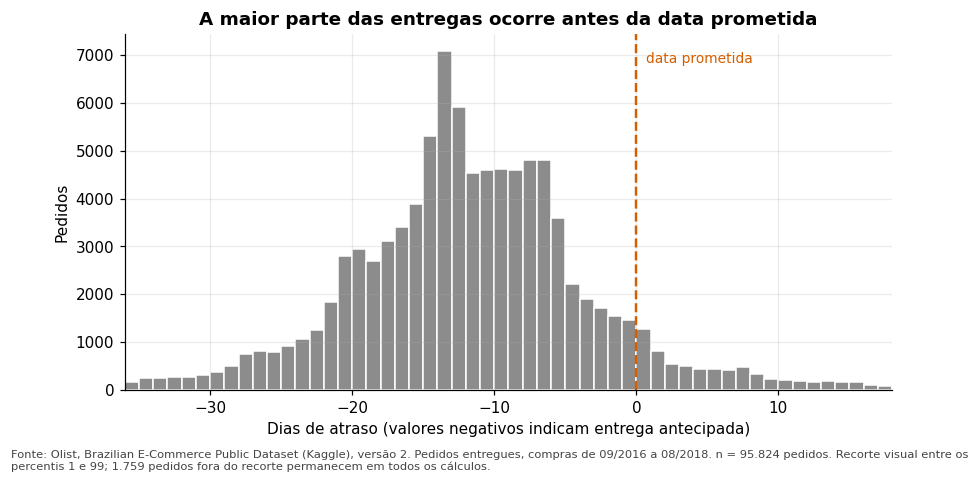

In [20]:
p01, p99 = base["atraso_dias"].quantile([0.01, 0.99])
fora_do_recorte = int(((base["atraso_dias"] < p01) | (base["atraso_dias"] > p99)).sum())

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.hist(base["atraso_dias"], bins=range(int(p01), int(p99) + 2), color=COR_NEUTRA, edgecolor="white")
ax.axvline(0, color=COR_ATRASADO, linewidth=1.6, linestyle="--")
ax.annotate("data prometida", xy=(0, ax.get_ylim()[1] * 0.92), xytext=(6, 0),
            textcoords="offset points", color=COR_ATRASADO, fontsize=9)
ax.set_title("A maior parte das entregas ocorre antes da data prometida")
ax.set_xlabel("Dias de atraso (valores negativos indicam entrega antecipada)")
ax.set_ylabel("Pedidos")
ax.set_xlim(p01, p99)
fig.text(0.01, -0.06,
         RODAPE_FONTE + f" Recorte visual entre os percentis 1 e 99; "
         f"{num(fora_do_recorte)} pedidos fora do recorte permanecem em todos os cálculos.",
         fontsize=7.5, color="#444444", wrap=True)
plt.show()

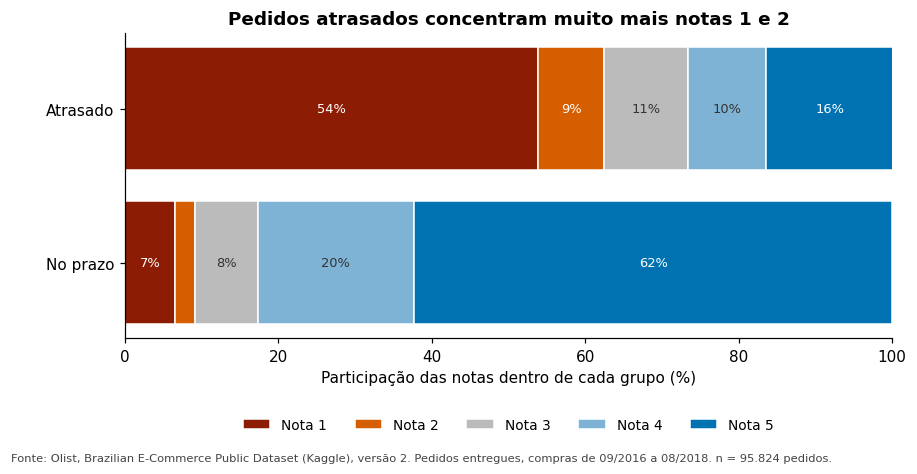

In [21]:
fig, ax = plt.subplots(figsize=(9, 3.6))
esquerda = np.zeros(len(distribuicao_notas))
cores_notas = ["#8C1D04", "#D55E00", "#BBBBBB", "#7FB3D5", COR_NO_PRAZO]

for i, nota in enumerate(distribuicao_notas.columns):
    valores = distribuicao_notas[nota].to_numpy()
    ax.barh(distribuicao_notas.index, valores, left=esquerda, color=cores_notas[i],
            edgecolor="white", label=f"Nota {int(nota)}")
    for y, (v, e) in enumerate(zip(valores, esquerda)):
        if v >= 4:
            ax.text(e + v / 2, y, f"{v:.0f}%".replace(".", ","), ha="center", va="center",
                    fontsize=8.5, color="white" if i in (0, 1, 4) else "#333333")
    esquerda += valores

ax.set_title("Pedidos atrasados concentram muito mais notas 1 e 2")
ax.set_xlabel("Participação das notas dentro de cada grupo (%)")
ax.set_xlim(0, 100)
ax.grid(False)
ax.legend(ncol=5, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.22), fontsize=9)
fig.text(0.01, -0.20, RODAPE_FONTE, fontsize=7.5, color="#444444", wrap=True)
plt.show()

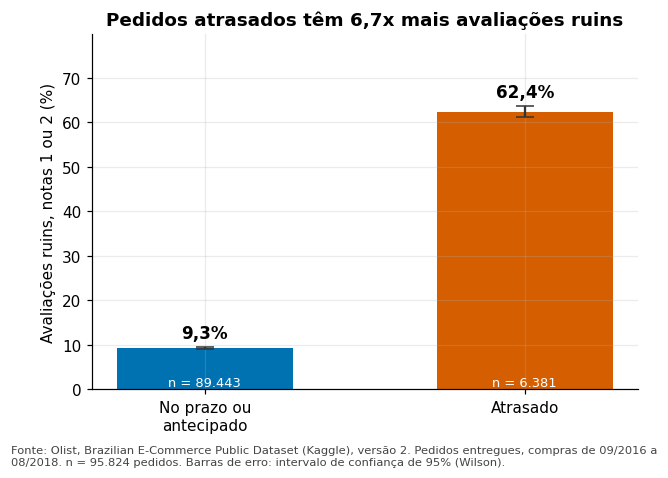

In [22]:
fig, ax = plt.subplots(figsize=(6.4, 4.2))
rotulos = ["No prazo ou\nantecipado", "Atrasado"]
taxas = [taxa_no_prazo, taxa_atrasados]
intervalos = [ic_no_prazo, ic_atrasados]
erros = np.array([[t - ic[0] for t, ic in zip(taxas, intervalos)],
                  [ic[1] - t for t, ic in zip(taxas, intervalos)]]) * 100

barras = ax.bar(rotulos, [100 * t for t in taxas], color=[COR_NO_PRAZO, COR_ATRASADO],
                width=0.55, yerr=erros, capsize=6, ecolor="#333333")
for barra, taxa, erro_superior, n in zip(barras, taxas, erros[1], [n_no_prazo, n_atrasados]):
    ax.text(barra.get_x() + barra.get_width() / 2, 100 * taxa + erro_superior + 2.0,
            pct(taxa, 1), ha="center", fontsize=11, fontweight="bold")
    ax.text(barra.get_x() + barra.get_width() / 2, 0.8, f"n = {num(n)}",
            ha="center", fontsize=8.5, color="white")

ax.set_title(f"Pedidos atrasados têm {dec(risco_relativo, 1)}x mais avaliações ruins")
ax.set_ylabel("Avaliações ruins, notas 1 ou 2 (%)")
ax.set_ylim(0, max(100 * t for t in taxas) * 1.28)
fig.text(0.01, -0.05, RODAPE_FONTE + " Barras de erro: intervalo de confiança de 95% (Wilson).",
         fontsize=7.5, color="#444444", wrap=True)
plt.show()

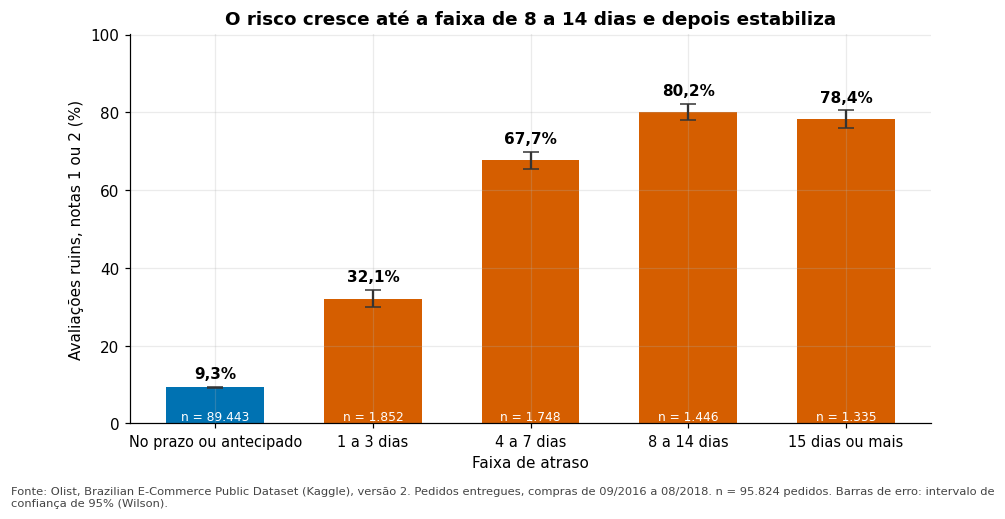

In [23]:
fig, ax = plt.subplots(figsize=(9.4, 4.6))
x = np.arange(len(por_faixa))
taxas_faixa = 100 * por_faixa["taxa"].to_numpy()
erro_faixa = np.array([
    taxas_faixa - 100 * por_faixa["ic_inferior"].to_numpy(),
    100 * por_faixa["ic_superior"].to_numpy() - taxas_faixa,
])
cores = [COR_NO_PRAZO] + [COR_ATRASADO] * (len(por_faixa) - 1)

barras = ax.bar(x, taxas_faixa, color=cores, width=0.62, yerr=erro_faixa,
                capsize=5, ecolor="#333333")
for barra, taxa, erro_superior, n in zip(barras, taxas_faixa, erro_faixa[1], por_faixa["pedidos"]):
    ax.text(barra.get_x() + barra.get_width() / 2, taxa + erro_superior + 2.2,
            f"{taxa:.1f}%".replace(".", ","), ha="center", fontsize=10, fontweight="bold")
    ax.text(barra.get_x() + barra.get_width() / 2, 0.8, f"n = {num(n)}",
            ha="center", fontsize=8, color="white")

titulo_faixas = (
    "O risco de avaliação ruim cresce com a duração do atraso"
    if risco_monotonico
    else f"O risco cresce até a faixa de {faixa_pico.lower()} e depois estabiliza"
)

ax.set_xticks(x)
ax.set_xticklabels(por_faixa.index, fontsize=9.5)
ax.set_title(titulo_faixas)
ax.set_ylabel("Avaliações ruins, notas 1 ou 2 (%)")
ax.set_xlabel("Faixa de atraso")
ax.set_ylim(0, taxas_faixa.max() * 1.25)
fig.text(0.01, -0.05, RODAPE_FONTE + " Barras de erro: intervalo de confiança de 95% (Wilson).",
         fontsize=7.5, color="#444444", wrap=True)
plt.show()

## 12. Inferência estatística e medidas de efeito

A inferência usa a variável binária `avaliacao_ruim`. A escala de 1 a 5 é ordinal e não é tratada
como contínua em teste paramétrico: a nota média aparece apenas como descrição.

Três resultados são reportados, com papéis distintos. O **teste de hipótese** responde se a
diferença observada é compatível com o acaso. A **diferença absoluta**, em pontos percentuais,
dá a magnitude para dimensionar a operação. O **risco relativo** dá a magnitude comparativa, que
é o que ordena a fila de atendimento.

In [24]:
# Medidas de efeito. O grupo 1 é o de atrasados, para que a diferença e a razão sejam
# lidas na direção da hipótese alternativa.
diferenca = taxa_atrasados - taxa_no_prazo
ic_diferenca = confint_proportions_2indep(
    ruins_atrasados, n_atrasados, ruins_no_prazo, n_no_prazo,
    compare="diff", method="newcomb", alpha=0.05,
)

risco_relativo = taxa_atrasados / taxa_no_prazo
ic_risco_relativo = confint_proportions_2indep(
    ruins_atrasados, n_atrasados, ruins_no_prazo, n_no_prazo,
    compare="ratio", method="log-adjusted", alpha=0.05,
)

for chave, valor in {
    "diferenca_absoluta": diferenca, "ic_diferenca": ic_diferenca,
    "risco_relativo": risco_relativo, "ic_risco_relativo": ic_risco_relativo,
}.items():
    registrar(chave, valor)

print(f"Diferença absoluta: {dec(100 * diferenca, 2)} pontos percentuais "
      f"(IC 95%: {dec(100 * ic_diferenca[0], 2)} a {dec(100 * ic_diferenca[1], 2)} p.p.)")
print(f"Risco relativo:     {dec(risco_relativo, 2)}x "
      f"(IC 95%: {dec(ic_risco_relativo[0], 2)} a {dec(ic_risco_relativo[1], 2)})")

Diferença absoluta: 53,15 pontos percentuais (IC 95%: 51,94 a 54,35 p.p.)
Risco relativo:     6,74x (IC 95%: 6,55 a 6,93)


In [25]:
# Teste da hipótese direcional. Dois métodos são reportados para mostrar que a conclusão
# não depende da escolha entre eles.
teste_score = test_proportions_2indep(
    ruins_atrasados, n_atrasados, ruins_no_prazo, n_no_prazo,
    compare="diff", method="score", alternative="larger", correction=True,
)

contagens = np.array([ruins_atrasados, ruins_no_prazo])
tamanhos = np.array([n_atrasados, n_no_prazo])
estatistica_z, valor_p_z = proportions_ztest(contagens, tamanhos, alternative="larger")

registrar("estatistica_score", float(teste_score.statistic))
registrar("valor_p_score", float(teste_score.pvalue))
registrar("estatistica_z", float(estatistica_z))
registrar("valor_p_z", float(valor_p_z))

def formatar_p(valor):
    # Valores-p extremamente pequenos não devem ser exibidos como zero.
    return "< 0,0001" if valor < 1e-4 else dec(valor, 4)

print("H0: taxa de avaliação ruim é igual nos dois grupos")
print("H1: taxa de avaliação ruim é MAIOR entre pedidos atrasados (unilateral à direita)")
print()
print(f"Teste de escore (Miettinen-Nurminen): estatística = {dec(teste_score.statistic, 2)}, "
      f"valor-p = {formatar_p(teste_score.pvalue)}")
print(f"Teste z de duas proporções (agrupado): estatística = {dec(estatistica_z, 2)}, "
      f"valor-p = {formatar_p(valor_p_z)}")

H0: taxa de avaliação ruim é igual nos dois grupos
H1: taxa de avaliação ruim é MAIOR entre pedidos atrasados (unilateral à direita)

Teste de escore (Miettinen-Nurminen): estatística = 122,75, valor-p = < 0,0001
Teste z de duas proporções (agrupado): estatística = 122,76, valor-p = < 0,0001


In [26]:
# Teste de tendência ordinal entre as faixas de atraso.
tabela_faixas = pd.crosstab(base["faixa_atraso"], base["avaliacao_ruim"])
escores_faixa = np.arange(len(tabela_faixas.index))
tendencia = Table(tabela_faixas.to_numpy()).test_ordinal_association(
    row_scores=escores_faixa, col_scores=np.array([0, 1])
)

registrar("estatistica_tendencia", float(tendencia.zscore))
registrar("valor_p_tendencia", float(tendencia.pvalue))

print("Teste de associação ordinal entre faixa de atraso e avaliação ruim")
print(f"Estatística z = {dec(tendencia.zscore, 2)}, valor-p = {formatar_p(tendencia.pvalue)}")

Teste de associação ordinal entre faixa de atraso e avaliação ruim
Estatística z = 128,76, valor-p = < 0,0001


In [27]:
# Risco relativo de cada faixa em relação à faixa de referência.
referencia = por_faixa.loc[FAIXA_REFERENCIA]
n_ref, ruins_ref = int(referencia["pedidos"]), int(referencia["avaliacoes_ruins"])

linhas_rr = []
for faixa, linha in por_faixa.iterrows():
    n_f, ruins_f = int(linha["pedidos"]), int(linha["avaliacoes_ruins"])
    if faixa == FAIXA_REFERENCIA:
        linhas_rr.append({"faixa_atraso": faixa, "rr": 1.0, "rr_inferior": np.nan, "rr_superior": np.nan})
        continue
    rr = (ruins_f / n_f) / (ruins_ref / n_ref)
    ic = confint_proportions_2indep(ruins_f, n_f, ruins_ref, n_ref,
                                    compare="ratio", method="log-adjusted", alpha=0.05)
    linhas_rr.append({"faixa_atraso": faixa, "rr": rr, "rr_inferior": ic[0], "rr_superior": ic[1]})

rr_faixa = pd.DataFrame(linhas_rr).set_index("faixa_atraso")
por_faixa = por_faixa.join(rr_faixa)

exibicao_rr = pd.DataFrame({
    "pedidos": por_faixa["pedidos"].map(num),
    "taxa": por_faixa["taxa"].map(pct),
    "risco relativo": [("referência" if np.isnan(lo) else f"{dec(r, 2)}x")
                       for r, lo in zip(por_faixa["rr"], por_faixa["rr_inferior"])],
    "IC 95% do risco relativo": [("—" if np.isnan(lo) else f"[{dec(lo, 2)} ; {dec(hi, 2)}]")
                                 for lo, hi in zip(por_faixa["rr_inferior"], por_faixa["rr_superior"])],
})
display(exibicao_rr)

,pedidos,taxa,risco relativo,IC 95% do risco relativo
faixa_atraso,,,,
No prazo ou antecipado,89.443,"9,27%",referência,—
1 a 3 dias,1.852,"32,13%","3,47x","[3,24 ; 3,72]"
4 a 7 dias,1.748,"67,68%","7,30x","[7,03 ; 7,59]"
8 a 14 dias,1.446,"80,15%","8,65x","[8,37 ; 8,94]"
15 dias ou mais,1.335,"78,35%","8,45x","[8,17 ; 8,75]"


### As duas faixas de maior atraso diferem entre si?

A resposta muda a operação. Se o risco crescesse indefinidamente, atrasos muito longos exigiriam
tratamento próprio. Se houver estabilização, as faixas superiores podem receber a mesma ação, o
que simplifica a regra e a execução.

In [28]:
faixa_penultima, faixa_ultima = por_faixa.index[-2], por_faixa.index[-1]
n_penultima = int(por_faixa.loc[faixa_penultima, "pedidos"])
ruins_penultima = int(por_faixa.loc[faixa_penultima, "avaliacoes_ruins"])
n_ultima = int(por_faixa.loc[faixa_ultima, "pedidos"])
ruins_ultima = int(por_faixa.loc[faixa_ultima, "avaliacoes_ruins"])

ic_topo = confint_proportions_2indep(
    ruins_ultima, n_ultima, ruins_penultima, n_penultima,
    compare="ratio", method="log-adjusted", alpha=0.05,
)
topo_indistinguivel = bool(ic_topo[0] <= 1.0 <= ic_topo[1])

registrar("ic_rr_topo", ic_topo)
registrar("topo_indistinguivel", topo_indistinguivel)

print(f"'{faixa_ultima}' contra '{faixa_penultima}': risco relativo "
      f"IC 95% [{dec(ic_topo[0], 2)} ; {dec(ic_topo[1], 2)}]")
print(f"Intervalo contém 1, faixas indistinguíveis: {topo_indistinguivel}")

'15 dias ou mais' contra '8 a 14 dias': risco relativo IC 95% [0,94 ; 1,02]
Intervalo contém 1, faixas indistinguíveis: True


## 13. Matriz de apoio à decisão

A prioridade é atribuída pelo **risco absoluto** de avaliação ruim, não pelo risco relativo. A
razão é operacional: o que determina o valor de acionar a equipe é a probabilidade de o cliente
ficar insatisfeito, não quantas vezes essa probabilidade supera a de outro grupo. Nesta base
todas as faixas de atraso têm risco relativo elevado, de modo que uma escada construída sobre o
risco relativo colocaria todas no mesmo degrau e não produziria triagem alguma.

| Condição | Prioridade | Ação de atendimento |
|---|---|---|
| Intervalo de confiança do risco relativo contém 1 | Sem diferenciação | Acompanhamento normal |
| Risco absoluto abaixo de 25% | Baixa | Comunicação automática |
| Risco absoluto de 25% a menos de 50% | Média | Contato humano proativo |
| Risco absoluto de 50% ou mais | Alta | Escalonamento e avaliação de compensação |

Os cortes em 25% e 50% são convenções operacionais, não valores extraídos dos dados. O corte de
50% tem leitura direta: acima dele é mais provável que o cliente avalie mal do que o contrário, o
que justifica o tratamento mais intenso. O que os dados determinam é **em qual degrau cada faixa
cai**.

A primeira linha é uma trava estatística: se o intervalo de confiança do risco relativo de uma
faixa contiver 1, não há evidência de risco diferente e nenhuma prioridade especial é atribuída,
ainda que a estimativa pontual seja maior. O degrau "Baixa" pode não ser acionado por nenhuma
faixa nesta execução; ele permanece na regra porque ela deve continuar válida se for reaplicada a
outro período ou a outra operação.

In [29]:
CORTE_RISCO_BAIXO = 0.25
CORTE_RISCO_ALTO = 0.50


def classificar(taxa, rr_inferior):
    # Aplica a escada declarada acima. A trava estatística vem primeiro.
    if np.isnan(rr_inferior):
        return "Referência", "Acompanhamento normal"
    if rr_inferior <= 1.0:
        return "Sem diferenciação", "Acompanhamento normal"
    if taxa < CORTE_RISCO_BAIXO:
        return "Baixa", "Comunicação automática"
    if taxa < CORTE_RISCO_ALTO:
        return "Média", "Contato humano proativo"
    return "Alta", "Escalonamento e avaliação de compensação"


classificacao = [classificar(t, lo) for t, lo in zip(por_faixa["taxa"], por_faixa["rr_inferior"])]
por_faixa["prioridade"] = [c[0] for c in classificacao]
por_faixa["acao"] = [c[1] for c in classificacao]

matriz_decisao = pd.DataFrame({
    "Faixa de atraso": por_faixa.index,
    "Pedidos": por_faixa["pedidos"].map(num).to_numpy(),
    "Taxa de avaliação ruim": por_faixa["taxa"].map(pct).to_numpy(),
    "Risco relativo": [("referência" if np.isnan(lo) else f"{dec(r, 2)}x")
                       for r, lo in zip(por_faixa["rr"], por_faixa["rr_inferior"])],
    "IC 95%": [("—" if np.isnan(lo) else f"[{dec(lo, 2)} ; {dec(hi, 2)}]")
               for lo, hi in zip(por_faixa["rr_inferior"], por_faixa["rr_superior"])],
    "Prioridade": por_faixa["prioridade"].to_numpy(),
    "Ação de atendimento": por_faixa["acao"].to_numpy(),
})

registrar("matriz_decisao", matriz_decisao)

faixas_priorizadas = por_faixa[~por_faixa["prioridade"].isin(["Referência", "Sem diferenciação"])]
registrar("pedidos_priorizados", int(faixas_priorizadas["pedidos"].sum()))
registrar("pct_pedidos_priorizados", float(faixas_priorizadas["pedidos"].sum() / len(base)))
registrar("faixas_sem_diferenciacao",
          list(por_faixa.index[por_faixa["prioridade"] == "Sem diferenciação"]))

display(matriz_decisao.style.hide(axis="index"))

Faixa de atraso,Pedidos,Taxa de avaliação ruim,Risco relativo,IC 95%,Prioridade,Ação de atendimento
No prazo ou antecipado,89.443,"9,27%",referência,—,Referência,Acompanhamento normal
1 a 3 dias,1.852,"32,13%","3,47x","[3,24 ; 3,72]",Média,Contato humano proativo
4 a 7 dias,1.748,"67,68%","7,30x","[7,03 ; 7,59]",Alta,Escalonamento e avaliação de compensação
8 a 14 dias,1.446,"80,15%","8,65x","[8,37 ; 8,94]",Alta,Escalonamento e avaliação de compensação
15 dias ou mais,1.335,"78,35%","8,45x","[8,17 ; 8,75]",Alta,Escalonamento e avaliação de compensação


In [30]:
carga = (
    por_faixa.groupby("prioridade", observed=True)["pedidos"].sum()
    .drop(labels=["Referência"], errors="ignore")
    .sort_values(ascending=False)
)
meses = (RESULTADOS["periodo_fim"].to_period("M") - RESULTADOS["periodo_inicio"].to_period("M")).n + 1
registrar("meses_periodo", int(meses))
registrar("carga_por_prioridade", carga.to_dict())

carga_exibicao = pd.DataFrame({
    "Prioridade": carga.index,
    "Pedidos no período": [num(v) for v in carga.to_numpy()],
    "% da amostra": [pct(v / len(base), 1) for v in carga.to_numpy()],
    "Média por mês": [num(round(v / meses)) for v in carga.to_numpy()],
})
display(carga_exibicao.style.hide(axis="index"))

display(Markdown(
    f"A regra seleciona **{num(RESULTADOS['pedidos_priorizados'])} pedidos** para algum nível de "
    f"acompanhamento diferenciado, o equivalente a "
    f"**{pct(RESULTADOS['pct_pedidos_priorizados'], 1)} da amostra**, distribuídos ao longo de "
    f"{num(meses)} meses. Esse é o dimensionamento que a operação precisa absorver caso adote a "
    f"regra integralmente. A coluna de média mensal é a informação relevante para decidir se a "
    f"equipe atual comporta a carga."
))

Prioridade,Pedidos no período,% da amostra,Média por mês
Alta,4.529,"4,7%",189
Média,1.852,"1,9%",77


A regra seleciona **6.381 pedidos** para algum nível de acompanhamento diferenciado, o equivalente a **6,7% da amostra**, distribuídos ao longo de 24 meses. Esse é o dimensionamento que a operação precisa absorver caso adote a regra integralmente. A coluna de média mensal é a informação relevante para decidir se a equipe atual comporta a carga.

## 14. Conclusões

O texto abaixo é gerado a partir dos valores calculados. Nenhum número foi digitado manualmente.

In [31]:
faixa_maior_risco = por_faixa["taxa"].idxmax()
taxa_maior_risco = por_faixa.loc[faixa_maior_risco, "taxa"]
rr_maior_risco = por_faixa.loc[faixa_maior_risco, "rr"]
registrar("faixa_maior_risco", faixa_maior_risco)
registrar("taxa_maior_risco", float(taxa_maior_risco))
registrar("rr_maior_risco", float(rr_maior_risco))

# A descrição da forma da curva é derivada do resultado, não escrita de antemão.
if risco_monotonico:
    descricao_forma = (
        "As taxas observadas formam uma sequência estritamente crescente ao longo das faixas."
    )
else:
    descricao_forma = (
        f"O crescimento não é monotônico até o fim da escala: as taxas sobem acentuadamente até "
        f"a faixa de {faixa_pico.lower()} e depois estabilizam. A comparação direta entre as duas "
        f"faixas de maior atraso tem risco relativo com intervalo de confiança de 95% "
        f"[{dec(RESULTADOS['ic_rr_topo'][0], 2)} ; {dec(RESULTADOS['ic_rr_topo'][1], 2)}], que "
        f"{'contém' if RESULTADOS['topo_indistinguivel'] else 'não contém'} o valor 1. "
        f"{'Não há, portanto, evidência de que atrasos muito longos elevem o risco além do patamar já atingido.' if RESULTADOS['topo_indistinguivel'] else 'As duas faixas superiores diferem entre si.'}"
    )

paragrafos = [
    f"**Resposta à pergunta.** Sim. Entre os {num(len(base))} pedidos entregues analisados, a "
    f"taxa de avaliação ruim foi de {pct(taxa_atrasados)} nos pedidos atrasados contra "
    f"{pct(taxa_no_prazo)} nos entregues no prazo ou antecipadamente. A diferença é de "
    f"{dec(100 * diferenca, 1)} pontos percentuais (IC 95%: {dec(100 * ic_diferenca[0], 1)} a "
    f"{dec(100 * ic_diferenca[1], 1)} p.p.), o que corresponde a um risco relativo de "
    f"{dec(risco_relativo, 2)}x (IC 95%: {dec(ic_risco_relativo[0], 2)} a "
    f"{dec(ic_risco_relativo[1], 2)}).",

    f"**Decisão sobre a hipótese.** O teste unilateral rejeita $H_0$ ao nível de 5% "
    f"(valor-p {formatar_p(RESULTADOS['valor_p_score'])}). Com uma amostra deste tamanho "
    f"quase qualquer "
    f"diferença seria detectável, e por isso a conclusão se apoia na magnitude: o intervalo de "
    f"confiança do risco relativo está inteiramente acima de {dec(ic_risco_relativo[0], 1)}, "
    f"diferença grande o bastante para orientar decisão operacional.",

    f"**Como o risco varia com a duração do atraso.** Existe associação ordinal positiva forte "
    f"entre faixa de atraso e avaliação ruim (valor-p "
    f"{formatar_p(RESULTADOS['valor_p_tendencia'])}). {descricao_forma} A faixa de maior risco "
    f"observado é **{faixa_maior_risco}**, com taxa de {pct(taxa_maior_risco)} e risco relativo "
    f"de {dec(rr_maior_risco, 2)}x em relação aos pedidos entregues no prazo.",

    f"**Implicação para a decisão.** O número de dias de atraso é um critério de triagem útil e "
    f"barato: já está disponível no momento da entrega, não exige modelo preditivo e ordena os "
    f"pedidos por risco de insatisfação. A regra da seção 13 seleciona "
    f"{pct(RESULTADOS['pct_pedidos_priorizados'], 1)} da base para acompanhamento diferenciado.",

    "**Limite da inferência.** Estes são dados observacionais. Os resultados mostram que atraso "
    "e avaliação ruim estão fortemente associados e que o risco cresce com a duração do atraso "
    "até um patamar. Eles não estabelecem que o atraso seja a causa da nota baixa, nem que "
    "contatar o cliente elevaria a avaliação.",
]

display(Markdown("\n\n".join(paragrafos)))

**Resposta à pergunta.** Sim. Entre os 95.824 pedidos entregues analisados, a taxa de avaliação ruim foi de 62,42% nos pedidos atrasados contra 9,27% nos entregues no prazo ou antecipadamente. A diferença é de 53,2 pontos percentuais (IC 95%: 51,9 a 54,3 p.p.), o que corresponde a um risco relativo de 6,74x (IC 95%: 6,55 a 6,93).

**Decisão sobre a hipótese.** O teste unilateral rejeita $H_0$ ao nível de 5% (valor-p < 0,0001). Com uma amostra deste tamanho quase qualquer diferença seria detectável, e por isso a conclusão se apoia na magnitude: o intervalo de confiança do risco relativo está inteiramente acima de 6,5, diferença grande o bastante para orientar decisão operacional.

**Como o risco varia com a duração do atraso.** Existe associação ordinal positiva forte entre faixa de atraso e avaliação ruim (valor-p < 0,0001). O crescimento não é monotônico até o fim da escala: as taxas sobem acentuadamente até a faixa de 8 a 14 dias e depois estabilizam. A comparação direta entre as duas faixas de maior atraso tem risco relativo com intervalo de confiança de 95% [0,94 ; 1,02], que contém o valor 1. Não há, portanto, evidência de que atrasos muito longos elevem o risco além do patamar já atingido. A faixa de maior risco observado é **8 a 14 dias**, com taxa de 80,15% e risco relativo de 8,65x em relação aos pedidos entregues no prazo.

**Implicação para a decisão.** O número de dias de atraso é um critério de triagem útil e barato: já está disponível no momento da entrega, não exige modelo preditivo e ordena os pedidos por risco de insatisfação. A regra da seção 13 seleciona 6,7% da base para acompanhamento diferenciado.

**Limite da inferência.** Estes são dados observacionais. Os resultados mostram que atraso e avaliação ruim estão fortemente associados e que o risco cresce com a duração do atraso até um patamar. Eles não estabelecem que o atraso seja a causa da nota baixa, nem que contatar o cliente elevaria a avaliação.

## 15. Limitações e próximos passos

**Natureza observacional.** Não houve atribuição aleatória de atraso. Pedidos atrasados podem
diferir dos demais em características não observadas aqui, como categoria do produto, região,
vendedor, valor do pedido ou frete. Qualquer uma delas pode contribuir tanto para o atraso quanto
para a insatisfação. O escopo desta atividade usa apenas duas tabelas e portanto não controla
esses fatores.

**Seleção pelas avaliações.** Só entram na análise pedidos que receberam avaliação. Se a
propensão a avaliar depender da experiência de entrega, as taxas observadas ficam enviesadas.
Este risco não é hipotético neste conjunto: a subseção seguinte mede a diferença e delimita o
quanto ela poderia deslocar o resultado.

**Recorte histórico e de plataforma.** Os dados cobrem um período específico de uma plataforma
brasileira. Prazos prometidos, mix de produtos e comportamento do consumidor mudam. As magnitudes
não devem ser transportadas para outra operação sem nova medição.

**Medida de atraso.** O atraso é calculado contra a data prometida registrada no pedido, não
contra a data comunicada ao cliente em eventuais atualizações. Se a operação reprogramar prazos e
avisar o cliente, o atraso percebido difere do atraso medido aqui.

**Escala das notas.** A nota é ordinal e foi dicotomizada em 1 ou 2 contra 3 a 5. A dicotomização
descarta informação: uma queda de 5 para 3 não aparece na variável analisada.

### Próximos passos

O passo que efetivamente responderia à pergunta causal é um **teste A/B**: sortear, entre os
pedidos atrasados de uma mesma faixa, quais recebem contato proativo e quais seguem o fluxo
padrão, comparando as avaliações posteriores. Só esse desenho permite afirmar que a ação de
atendimento altera a nota.

Antes disso, dois refinamentos são baratos e úteis. Estratificar por categoria de produto e por
região indicaria se a associação é homogênea entre segmentos ou concentrada em alguns deles.
Monitorar a taxa de avaliação ruim por faixa ao longo do tempo mostraria se a relação se mantém
estável, que é a premissa implícita de usar a regra em produção.

### Quantificação das duas escolhas de tratamento que poderiam alterar o resultado

Duas decisões tomadas na preparação dos dados admitiam alternativa razoável: qual avaliação
conservar quando um pedido tem mais de uma, e o que fazer com os pedidos entregues que nunca
receberam avaliação. Cada uma é avaliada pelo quanto desloca o resultado, e não por argumento.

In [32]:
# Escolha 1: conservar a avaliação mais recente ou a mais antiga.
duplicadas = avaliacoes_validas[avaliacoes_validas["order_id"].duplicated(keep=False)]
notas_por_pedido = duplicadas.groupby("order_id")["review_score"].nunique()
n_divergentes = int((notas_por_pedido > 1).sum())

avaliacoes_antigas = avaliacoes_ordenadas.drop_duplicates(subset="order_id", keep="first")
base_alternativa = pedidos_validos.merge(
    avaliacoes_antigas[["order_id", "review_score"]],
    on="order_id", how="inner", validate="one_to_one",
)
base_alternativa["atraso_dias"] = calcular_atraso(base_alternativa)
base_alternativa["pedido_atrasado"] = base_alternativa["atraso_dias"] > 0
base_alternativa["avaliacao_ruim"] = base_alternativa["review_score"] <= 2

taxa_alt_atrasados = base_alternativa.loc[base_alternativa["pedido_atrasado"], "avaliacao_ruim"].mean()
taxa_alt_no_prazo = base_alternativa.loc[~base_alternativa["pedido_atrasado"], "avaliacao_ruim"].mean()
rr_alternativo = taxa_alt_atrasados / taxa_alt_no_prazo

registrar("pedidos_duplicados_com_notas_divergentes", n_divergentes)
registrar("rr_conservando_mais_antiga", float(rr_alternativo))

print(f"Pedidos com mais de uma avaliação: "
      f"{num(RESULTADOS['pedidos_com_multiplas_avaliacoes'])}")
print(f"  destes, com notas divergentes entre si: {num(n_divergentes)}")
print(f"Risco relativo conservando a mais recente (regra adotada): {dec(risco_relativo, 3)}")
print(f"Risco relativo conservando a mais antiga  (alternativa):   {dec(rr_alternativo, 3)}")

Pedidos com mais de uma avaliação: 547
  destes, com notas divergentes entre si: 202
Risco relativo conservando a mais recente (regra adotada): 6,735
Risco relativo conservando a mais antiga  (alternativa):   6,734


In [33]:
# Escolha 2: limites do viés causado pelos pedidos entregues sem avaliação.
sem_avaliacao = pedidos_validos[~pedidos_validos["order_id"].isin(base["order_id"])].copy()
sem_avaliacao["atraso_dias"] = calcular_atraso(sem_avaliacao)
sem_avaliacao["pedido_atrasado"] = sem_avaliacao["atraso_dias"] > 0

pct_atrasados_sem_avaliacao = sem_avaliacao["pedido_atrasado"].mean()
n_atrasados_sem_avaliacao = int(sem_avaliacao["pedido_atrasado"].sum())

# Cenários extremos: os atrasados sem avaliação teriam todos avaliado bem, ou todos mal.
n_limite = n_atrasados + n_atrasados_sem_avaliacao
rr_piso = ((ruins_atrasados) / n_limite) / taxa_no_prazo
rr_teto = ((ruins_atrasados + n_atrasados_sem_avaliacao) / n_limite) / taxa_no_prazo

registrar("pct_atrasados_entre_sem_avaliacao", float(pct_atrasados_sem_avaliacao))
registrar("rr_piso_cenario_extremo", float(rr_piso))
registrar("rr_teto_cenario_extremo", float(rr_teto))

print(f"Pedidos atrasados entre os que TÊM avaliação:   "
      f"{pct(RESULTADOS['pct_pedidos_atrasados'], 2)}")
print(f"Pedidos atrasados entre os que NÃO têm:         {pct(pct_atrasados_sem_avaliacao, 2)}")
print()
print(f"Cenário extremo, todos avaliariam bem: risco relativo = {dec(rr_piso, 2)}")
print(f"Cenário extremo, todos avaliariam mal: risco relativo = {dec(rr_teto, 2)}")

Pedidos atrasados entre os que TÊM avaliação:   6,66%
Pedidos atrasados entre os que NÃO têm:         23,68%

Cenário extremo, todos avaliariam bem: risco relativo = 6,58
Cenário extremo, todos avaliariam mal: risco relativo = 6,83


In [34]:
display(Markdown(
    f"**Leitura das duas verificações.** A regra de deduplicação não é neutra para "
    f"{num(RESULTADOS['pedidos_duplicados_com_notas_divergentes'])} pedidos, cujas avaliações "
    f"repetidas têm notas diferentes entre si, mas a conclusão não depende dela: o risco relativo "
    f"vai de {dec(risco_relativo, 3)} para {dec(RESULTADOS['rr_conservando_mais_antiga'], 3)} se "
    f"a avaliação mais antiga for conservada.\n\n"
    f"O viés de seleção existe e tem direção definida: entre os pedidos sem avaliação, "
    f"{pct(RESULTADOS['pct_atrasados_entre_sem_avaliacao'], 1)} estavam atrasados, contra "
    f"{pct(RESULTADOS['pct_pedidos_atrasados'], 1)} entre os pedidos analisados. Pedidos "
    f"atrasados avaliam menos, o que significa que a análise exclui desproporcionalmente casos "
    f"de atraso. Como esses pedidos são apenas "
    f"{pct(RESULTADOS['pct_pedidos_sem_avaliacao'], 2)} do total apto, o deslocamento possível é "
    f"limitado: mesmo nos dois cenários extremos, em que todos eles teriam avaliado bem ou todos "
    f"teriam avaliado mal, o risco relativo permanece entre "
    f"{dec(RESULTADOS['rr_piso_cenario_extremo'], 2)} e "
    f"{dec(RESULTADOS['rr_teto_cenario_extremo'], 2)}. A conclusão não se altera."
))

**Leitura das duas verificações.** A regra de deduplicação não é neutra para 202 pedidos, cujas avaliações repetidas têm notas diferentes entre si, mas a conclusão não depende dela: o risco relativo vai de 6,735 para 6,734 se a avaliação mais antiga for conservada.

O viés de seleção existe e tem direção definida: entre os pedidos sem avaliação, 23,7% estavam atrasados, contra 6,7% entre os pedidos analisados. Pedidos atrasados avaliam menos, o que significa que a análise exclui desproporcionalmente casos de atraso. Como esses pedidos são apenas 0,67% do total apto, o deslocamento possível é limitado: mesmo nos dois cenários extremos, em que todos eles teriam avaliado bem ou todos teriam avaliado mal, o risco relativo permanece entre 6,58 e 6,83. A conclusão não se altera.

## 16. Informações de reprodutibilidade

Esta seção fecha o notebook com três controles: a conferência do resumo executivo contra os
valores calculados, o quadro completo de verificações e o registro das versões utilizadas.

In [35]:
# Confere cada número declarado no resumo executivo contra o valor recalculado.
# Se o resumo for editado sem que a análise mude, ou o contrário, a conferência falha.
RESUMO_DECLARADO = {
    "amostra final": ("95.824", lambda: num(RESULTADOS["n_amostra_final"])),
    "taxa no prazo": ("9,27%", lambda: pct(RESULTADOS["taxa_no_prazo"])),
    "taxa atrasados": ("62,42%", lambda: pct(RESULTADOS["taxa_atrasados"])),
    "risco relativo": ("6,74", lambda: dec(RESULTADOS["risco_relativo"], 2)),
    "diferença em pontos percentuais": ("53,2", lambda: dec(100 * RESULTADOS["diferenca_absoluta"], 1)),
    "taxa de 1 a 3 dias": ("32,13%", lambda: pct(por_faixa.loc["1 a 3 dias", "taxa"])),
    "taxa de 4 a 7 dias": ("67,68%", lambda: pct(por_faixa.loc["4 a 7 dias", "taxa"])),
    "taxa de 8 a 14 dias": ("80,15%", lambda: pct(por_faixa.loc["8 a 14 dias", "taxa"])),
    "taxa de 15 dias ou mais": ("78,35%", lambda: pct(por_faixa.loc["15 dias ou mais", "taxa"])),
    "carga mensal de prioridade alta": (
        "189", lambda: num(round(RESULTADOS["carga_por_prioridade"]["Alta"] / RESULTADOS["meses_periodo"]))),
    "carga mensal de prioridade média": (
        "77", lambda: num(round(RESULTADOS["carga_por_prioridade"]["Média"] / RESULTADOS["meses_periodo"]))),
}

marco = len(VERIFICACOES)
for nome, (declarado, recalcular) in RESUMO_DECLARADO.items():
    checar(f"Resumo executivo confere: {nome}", declarado == recalcular(),
           f"declarado {declarado}, recalculado {recalcular()}")

display(quadro_verificacoes(marco))

,verificação,resultado,detalhe
0,Resumo executivo confere: amostra final,PASSOU,"declarado 95.824, recalculado 95.824"
1,Resumo executivo confere: taxa no prazo,PASSOU,"declarado 9,27%, recalculado 9,27%"
2,Resumo executivo confere: taxa atrasados,PASSOU,"declarado 62,42%, recalculado 62,42%"
3,Resumo executivo confere: risco relativo,PASSOU,"declarado 6,74, recalculado 6,74"
4,Resumo executivo confere: diferença em pontos ...,PASSOU,"declarado 53,2, recalculado 53,2"
5,Resumo executivo confere: taxa de 1 a 3 dias,PASSOU,"declarado 32,13%, recalculado 32,13%"
6,Resumo executivo confere: taxa de 4 a 7 dias,PASSOU,"declarado 67,68%, recalculado 67,68%"
7,Resumo executivo confere: taxa de 8 a 14 dias,PASSOU,"declarado 80,15%, recalculado 80,15%"
8,Resumo executivo confere: taxa de 15 dias ou mais,PASSOU,"declarado 78,35%, recalculado 78,35%"
9,Resumo executivo confere: carga mensal de prio...,PASSOU,"declarado 189, recalculado 189"


In [36]:
quadro = pd.DataFrame(VERIFICACOES)
falhas = quadro[quadro["resultado"] == "FALHOU"]

print(f"Verificações executadas: {len(quadro)} | aprovadas: {len(quadro) - len(falhas)} | "
      f"falhas: {len(falhas)}")
display(quadro)

if len(falhas) > 0:
    raise AssertionError(
        f"{len(falhas)} verificação(ões) falharam. O notebook não deve ser considerado válido: "
        f"{list(falhas['verificação'])}"
    )

print("Todas as verificações passaram.")

Verificações executadas: 29 | aprovadas: 29 | falhas: 0


,verificação,resultado,detalhe
0,Colunas esperadas presentes em pedidos,PASSOU,ausentes: []
1,Colunas esperadas presentes em avaliações,PASSOU,ausentes: []
2,order_id é único na tabela de pedidos,PASSOU,condição necessária para a unidade de análise ...
3,order_id é único após a deduplicação das avali...,PASSOU,pré-requisito da junção um-para-um
4,Deduplicação é determinística pelo horário da ...,PASSOU,empates de horário dentro do mesmo pedido: 0
5,Junção validada como um-para-um pelo pandas,PASSOU,validate='one_to_one' não levantou MergeError
6,order_id é único na base analítica,PASSOU,
7,Funil é monotonicamente decrescente,PASSOU,nenhuma etapa pode aumentar a contagem
8,Amostra final não é vazia,PASSOU,
9,Sem valores ausentes nas variáveis centrais,PASSOU,nulos encontrados: 0


Todas as verificações passaram.


In [37]:
import sys

versoes = pd.DataFrame(
    [
        ("Python", sys.version.split()[0]),
        ("numpy", np.__version__),
        ("pandas", pd.__version__),
        ("matplotlib", mpl.__version__),
        ("statsmodels", statsmodels.__version__),
        ("kagglehub", kagglehub.__version__),
        ("Conjunto de dados", DATASET),
        ("Executado em", datetime.datetime.now().strftime("%d/%m/%Y %H:%M")),
    ],
    columns=["item", "valor"],
)
display(versoes.style.hide(axis="index"))

item,valor
Python,3.13.14
numpy,2.4.4
pandas,3.0.2
matplotlib,3.10.9
statsmodels,0.14.6
kagglehub,1.0.2
Conjunto de dados,olistbr/brazilian-ecommerce/versions/2
Executado em,01/09/2026 16:51


In [38]:
# Bloco de números para o README. Copiar da saída, sem retipar.
print("Período analisado:            "
      f"{RESULTADOS['periodo_inicio']:%m/%Y} a {RESULTADOS['periodo_fim']:%m/%Y}")
print(f"Pedidos brutos:               {num(RESULTADOS['n_pedidos_brutos'])}")
print(f"Amostra final:                {num(RESULTADOS['n_amostra_final'])}")
print(f"Pedidos atrasados:            {num(RESULTADOS['n_atrasados'])} "
      f"({pct(RESULTADOS['pct_pedidos_atrasados'], 1)})")
print(f"Taxa ruim, no prazo:          {pct(RESULTADOS['taxa_no_prazo'])}")
print(f"Taxa ruim, atrasados:         {pct(RESULTADOS['taxa_atrasados'])}")
print(f"Diferença absoluta:           {dec(100 * RESULTADOS['diferenca_absoluta'], 1)} p.p. "
      f"(IC 95%: {dec(100 * RESULTADOS['ic_diferenca'][0], 1)} a "
      f"{dec(100 * RESULTADOS['ic_diferenca'][1], 1)})")
print(f"Risco relativo:               {dec(RESULTADOS['risco_relativo'], 2)}x "
      f"(IC 95%: {dec(RESULTADOS['ic_risco_relativo'][0], 2)} a "
      f"{dec(RESULTADOS['ic_risco_relativo'][1], 2)})")
print(f"Valor-p (unilateral):         {formatar_p(RESULTADOS['valor_p_score'])}")
print(f"Faixa de maior risco:         {RESULTADOS['faixa_maior_risco']} "
      f"({pct(RESULTADOS['taxa_maior_risco'])}, "
      f"{dec(RESULTADOS['rr_maior_risco'], 2)}x)")
print(f"Selecionados pela regra:      {num(RESULTADOS['pedidos_priorizados'])} "
      f"({pct(RESULTADOS['pct_pedidos_priorizados'], 1)})")

Período analisado:            09/2016 a 08/2018
Pedidos brutos:               99.441
Amostra final:                95.824
Pedidos atrasados:            6.381 (6,7%)
Taxa ruim, no prazo:          9,27%
Taxa ruim, atrasados:         62,42%
Diferença absoluta:           53,2 p.p. (IC 95%: 51,9 a 54,3)
Risco relativo:               6,74x (IC 95%: 6,55 a 6,93)
Valor-p (unilateral):         < 0,0001
Faixa de maior risco:         8 a 14 dias (80,15%, 8,65x)
Selecionados pela regra:      6.381 (6,7%)
